In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

sns.set(style='whitegrid')

Initialized required libraries to start analysis and create visualizations.

In [83]:
file_name = 'https://raw.githubusercontent.com/amohanlall/my_vision/refs/heads/main/New_York_City_Leading_Causes_of_Death_20251220.csv'
df = pd.read_csv(file_name)
df.head()

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2014,Influenza (Flu) and Pneumonia (J09-J18),M,White Non-Hispanic,502,37.4,29.7
1,2014,Human Immunodeficiency Virus Disease (HIV: B20...,F,Not Stated/Unknown,7,.,.
2,2014,Human Immunodeficiency Virus Disease (HIV: B20...,M,Black Non-Hispanic,196,22.7,21.7
3,2014,"Intentional Self-Harm (Suicide: X60-X84, Y87.0)",M,White Non-Hispanic,204,15.2,13.4
4,2014,Malignant Neoplasms (Cancer: C00-C97),F,Hispanic,1154,91.1,97.4


Uploaded the above CSV file to extract the data

In [84]:
print('Shape (rows, columns):', df.shape)

print('\nColumn names:')
print(df.columns)

print('\nData types and non-null counts:')
df.info()

print('\nSummary statistics (numeric columns):')
df.describe()

Shape (rows, columns): (1094, 7)

Column names:
Index(['Year', 'Leading Cause', 'Sex', 'Race Ethnicity', 'Deaths',
       'Death Rate', 'Age Adjusted Death Rate'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     1094 non-null   int64 
 1   Leading Cause            1094 non-null   object
 2   Sex                      1094 non-null   object
 3   Race Ethnicity           1094 non-null   object
 4   Deaths                   1094 non-null   object
 5   Death Rate               1094 non-null   object
 6   Age Adjusted Death Rate  1094 non-null   object
dtypes: int64(1), object(6)
memory usage: 60.0+ KB

Summary statistics (numeric columns):


,Year
count,"1,094.00"
mean,"2,010.48"
std,2.29
min,"2,007.00"
25%,"2,008.00"
50%,"2,010.00"
75%,"2,012.00"
max,"2,014.00"


Examined column names and data samples to get a general sense of the statistics for analysis

In [85]:
# First 10 rows
df.head(10)

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2014,Influenza (Flu) and Pneumonia (J09-J18),M,White Non-Hispanic,502,37.4,29.7
1,2014,Human Immunodeficiency Virus Disease (HIV: B20...,F,Not Stated/Unknown,7,.,.
2,2014,Human Immunodeficiency Virus Disease (HIV: B20...,M,Black Non-Hispanic,196,22.7,21.7
3,2014,"Intentional Self-Harm (Suicide: X60-X84, Y87.0)",M,White Non-Hispanic,204,15.2,13.4
4,2014,Malignant Neoplasms (Cancer: C00-C97),F,Hispanic,1154,91.1,97.4
5,2014,Essential Hypertension and Renal Diseases (I10...,M,Not Stated/Unknown,9,.,.
6,2014,Diabetes Mellitus (E10-E14),F,Other Race/ Ethnicity,11,.,.
7,2014,Mental and Behavioral Disorders due to Acciden...,F,Not Stated/Unknown,6,.,.
8,2014,Malignant Neoplasms (Cancer: C00-C97),M,Not Stated/Unknown,73,.,.
9,2014,Cerebrovascular Disease (Stroke: I60-I69),M,White Non-Hispanic,277,20.6,16.8


Displayed the first 10 rows to better understand the dataset structure and determine which variables to analyze and compare

In [86]:
# Random sample of 5 rows
df.sample(5, random_state=42)

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
482,2011,Influenza (Flu) and Pneumonia (J09-J18),F,Other Race/ Ethnicity,6,.,.
139,2013,All Other Causes,F,Hispanic,1082,86.7,94
88,2014,Chronic Lower Respiratory Diseases (J40-J47),F,Hispanic,193,15.2,16.8
939,2008,Malignant Neoplasms (Cancer: C00-C97),M,Not Stated/Unknown,60,.,.
732,2009,Mental and Behavioral Disorders due to Acciden...,F,Hispanic,57,4.8,4.7


In [87]:
# Summary statistics for all columns (numeric + non-numeric)
df.describe(include='all')

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
count,"1,094.00",1094,1094,1094,1094,1094,1094
unique,NaN,26,2,6,465,442,427
top,NaN,Influenza (Flu) and Pneumonia (J09-J18),F,Not Stated/Unknown,.,.,.
freq,NaN,96,554,200,138,386,386
mean,"2,010.48",NaN,NaN,NaN,NaN,NaN,NaN
std,2.29,NaN,NaN,NaN,NaN,NaN,NaN
min,"2,007.00",NaN,NaN,NaN,NaN,NaN,NaN
25%,"2,008.00",NaN,NaN,NaN,NaN,NaN,NaN
50%,"2,010.00",NaN,NaN,NaN,NaN,NaN,NaN
75%,"2,012.00",NaN,NaN,NaN,NaN,NaN,NaN


Generating summary statistics helps identify potential data quality issues such as missing values, outliers, or skewed distributions. It also provides insight into whether the data requires cleaning or transformation.

In [109]:
df.tail(10)

,year,leading_cause,sex,race_ethnicity,deaths,death_rate,age_adjusted_death_rate
1084,2007,Influenza (Flu) and Pneumonia (J09-J18),F,Black Non-Hispanic,295.00,28,26.90
1085,2007,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",F,White Non-Hispanic,"7,050.00",491.4,250.70
1086,2007,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",M,Not Stated/Unknown,86.00,.,53.46
1087,2007,Cerebrovascular Disease (Stroke: I60-I69),M,Asian and Pacific Islander,56.00,11.6,16.20
1088,2007,Diabetes Mellitus (E10-E14),F,Black Non-Hispanic,358.00,34,32.50
1089,2007,Influenza (Flu) and Pneumonia (J09-J18),F,Not Stated/Unknown,444.56,.,53.46
1090,2007,Essential Hypertension and Renal Diseases (I10...,F,Black Non-Hispanic,166.00,15.8,15.00
1091,2007,Essential Hypertension and Renal Diseases (I10...,F,Not Stated/Unknown,5.00,.,53.46
1092,2007,All Other Causes,F,Hispanic,820.00,70.2,85.60
1093,2007,"Congenital Malformations, Deformations, and Ch...",F,Other Race/ Ethnicity,444.56,.,53.46


Retrieved the last 10 rows of data to review the most recent observations and verify if any records contain missing values.

In [88]:
print('Missing values per column:')
print(df.isna().sum())

print('\nPercentage of missing values per column:')
print((df.isna().mean() * 100).round(2))

print('\nNumber of unique values per column:')
print(df.nunique())

Missing values per column:
Year                       0
Leading Cause              0
Sex                        0
Race Ethnicity             0
Deaths                     0
Death Rate                 0
Age Adjusted Death Rate    0
dtype: int64

Percentage of missing values per column:
Year                      0.00
Leading Cause             0.00
Sex                       0.00
Race Ethnicity            0.00
Deaths                    0.00
Death Rate                0.00
Age Adjusted Death Rate   0.00
dtype: float64

Number of unique values per column:
Year                         8
Leading Cause               26
Sex                          2
Race Ethnicity               6
Deaths                     465
Death Rate                 442
Age Adjusted Death Rate    427
dtype: int64


Identified missing data and assessed the number of unique values in each column to better understand the dataset structure.

In [89]:
# 1. Clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)
df.columns

Index(['year', 'leading_cause', 'sex', 'race_ethnicity', 'deaths',
       'death_rate', 'age_adjusted_death_rate'],
      dtype='object')

Normalized column names for uniformity, improving clarity and analytical accuracy

In [90]:
# Inspect unique values in death_rate
df['death_rate'].unique()[:20]

array(['37.4', '.', '22.7', '15.2', '91.1', '20.6', '17.4', '28', '12.7',
       '8', '15.9', '36.3', '318', '39.7', '146.4', '36.8', '26.1',
       '22.8', '16.1', '19.2'], dtype=object)

In [91]:
# Replace 'N/A' with actual NaN and convert to numeric
df['age_adjusted_death_rate'] = df['age_adjusted_death_rate'].replace('.', np.nan)
df['age_adjusted_death_rate'] = pd.to_numeric(df['age_adjusted_death_rate'], errors='coerce')
df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')
df[['age_adjusted_death_rate', 'deaths']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_adjusted_death_rate  708 non-null    float64
 1   deaths                   956 non-null    float64
dtypes: float64(2)
memory usage: 17.2 KB


Cleaned the dataset by replacing placeholder values like '.' with proper NaN so pandas could recognize missing data. Then I converted both columns to numeric types using pd.to_numeric(errors='coerce'), which turned invalid entries into NaN. Finally, I checked the results with .info() to confirm the columns were correctly converted and ready for analysis.

In [92]:
# Check missing values
df.isna().sum()

,0
year,0
leading_cause,0
sex,0
race_ethnicity,0
deaths,138
death_rate,0
age_adjusted_death_rate,386


In [93]:
# Mean imputation for age_adjusted_death_rate
age_adjusted_death_rate_mean = df['age_adjusted_death_rate'].mean()
df['age_adjusted_death_rate'] = df['age_adjusted_death_rate'].fillna(age_adjusted_death_rate_mean)

deaths_mean = df['deaths'].mean()
df['deaths'] = df['deaths'].fillna(deaths_mean)

df.isna().sum()

,0
year,0
leading_cause,0
sex,0
race_ethnicity,0
deaths,0
death_rate,0
age_adjusted_death_rate,0


filled in missing values for the age_adjusted_death_rate and deaths columns. By calculating each column’s mean and using .fillna(), you replaced all NaN values with the average, ensuring no missing data remained. A final check with .isna().sum() confirmed that all columns now have complete data.

In [94]:
# Check missing values
df.isna().sum()

,0
year,0
leading_cause,0
sex,0
race_ethnicity,0
deaths,0
death_rate,0
age_adjusted_death_rate,0


In [95]:
categorical_cols = [
    'leading_cause', 'sex', 'race_ethnicity',
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

df[categorical_cols].dtypes

,0
leading_cause,category
sex,category
race_ethnicity,category


Converting columns to categorical data type

In [96]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.describe()

,year,deaths,age_adjusted_death_rate
count,"1,094.00","1,094.00","1,094.00"
mean,"2,010.48",444.56,53.46
std,2.29,822.67,55.58
min,"2,007.00",5.00,2.50
25%,"2,008.00",47.00,16.95
50%,"2,010.00",186.00,53.46
75%,"2,012.00",444.56,53.46
max,"2,014.00","7,050.00",350.70


Extracted data categories containing numerical types (such as integers and floats) to gain a comprehensive overview of the data for modeling. This provides a statistical summary that highlights the distribution of the numerical variables

In [97]:
print('year:')
print(df['year'].describe())

print('\ndeaths:')
print(df['deaths'].describe())

print('\nsex:')
print(df['sex'].describe())

year:
count   1,094.00
mean    2,010.48
std         2.29
min     2,007.00
25%     2,008.00
50%     2,010.00
75%     2,012.00
max     2,014.00
Name: year, dtype: float64

deaths:
count   1,094.00
mean      444.56
std       822.67
min         5.00
25%        47.00
50%       186.00
75%       444.56
max     7,050.00
Name: deaths, dtype: float64

sex:
count     1094
unique       2
top          F
freq       554
Name: sex, dtype: object


This code generates charts to visualize the distribution of variables within the dataset and also provides a numerical summary for the selected categories

In [98]:
def show_category_distribution(col_name):
    counts = df[col_name].value_counts()
    percents = df[col_name].value_counts(normalize=True) * 100
    display(pd.DataFrame({'count': counts, 'percent': percents.round(2)}))

for col in ['year', 'leading_cause', 'sex', 'race_ethnicity', 'deaths', 'death_rate','age_adjusted_death_rate']:
    print(f'--- {col} ---')
    show_category_distribution(col)
    print()

--- year ---


,count,percent
year,,
2011,141,12.89
2007,141,12.89
2010,138,12.61
2014,136,12.43
2008,136,12.43
2009,135,12.34
2012,134,12.25
2013,133,12.16



--- leading_cause ---


,count,percent
leading_cause,,
All Other Causes,96,8.78
"Diseases of Heart (I00-I09, I11, I13, I20-I51)",96,8.78
Influenza (Flu) and Pneumonia (J09-J18),96,8.78
Malignant Neoplasms (Cancer: C00-C97),96,8.78
Diabetes Mellitus (E10-E14),92,8.41
Cerebrovascular Disease (Stroke: I60-I69),90,8.23
Chronic Lower Respiratory Diseases (J40-J47),88,8.04
"Accidents Except Drug Posioning (V01-X39, X43, X45-X59, Y85-Y86)",80,7.31
"Essential Hypertension and Renal Diseases (I10, I12)",75,6.86



--- sex ---


...

,count,percent
deaths,,
444.56,138,12.61
5.00,28,2.56
8.00,22,2.01
6.00,21,1.92
10.00,15,1.37
...,...,...
540.00,1,0.09
223.00,1,0.09
"1,109.00",1,0.09



--- death_rate ---


,count,percent
death_rate,,
.,386,35.28
13,7,0.64
17.3,7,0.64
5.8,6,0.55
6.7,6,0.55
...,...,...
80.2,1,0.09
17.4,1,0.09
91.1,1,0.09



--- age_adjusted_death_rate ---


,count,percent
age_adjusted_death_rate,,
53.46,386,35.28
6.30,6,0.55
17.90,6,0.55
21.40,6,0.55
16.40,5,0.46
...,...,...
40.10,1,0.09
157.80,1,0.09
113.40,1,0.09


This code defines a function that accepts a column name as input. It calculates two metrics for the specified column: the count of each unique value and its corresponding percentage. These results are then combined into a Pandas DataFrame and displayed.

In [102]:
# Get top 10 causes from the current df
top10_causes = (
    df.groupby('leading_cause')['deaths']
      .sum()
      .nlargest(10)
      .index
)

# Filter and clean categories for df_top10
df_top10 = df[df['leading_cause'].isin(top10_causes)].copy()
df_top10['leading_cause'] = pd.Categorical(df_top10['leading_cause'], categories=top10_causes, ordered=True)

df_top10[['leading_cause', 'sex', 'deaths']].head(10)

/tmp/ipython-input-647111974.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('leading_cause')['deaths']


,leading_cause,sex,deaths
0,Influenza (Flu) and Pneumonia (J09-J18),M,502.00
1,Human Immunodeficiency Virus Disease (HIV: B20...,F,7.00
2,Human Immunodeficiency Virus Disease (HIV: B20...,M,196.00
4,Malignant Neoplasms (Cancer: C00-C97),F,"1,154.00"
5,Essential Hypertension and Renal Diseases (I10...,M,9.00
6,Diabetes Mellitus (E10-E14),F,11.00
8,Malignant Neoplasms (Cancer: C00-C97),M,73.00
9,Cerebrovascular Disease (Stroke: I60-I69),M,277.00
10,Cerebrovascular Disease (Stroke: I60-I69),M,8.00
11,"Accidents Except Drug Posioning (V01-X39, X43,...",M,12.00


Pulled the top 10 leading causes of deaths to compare and contrast

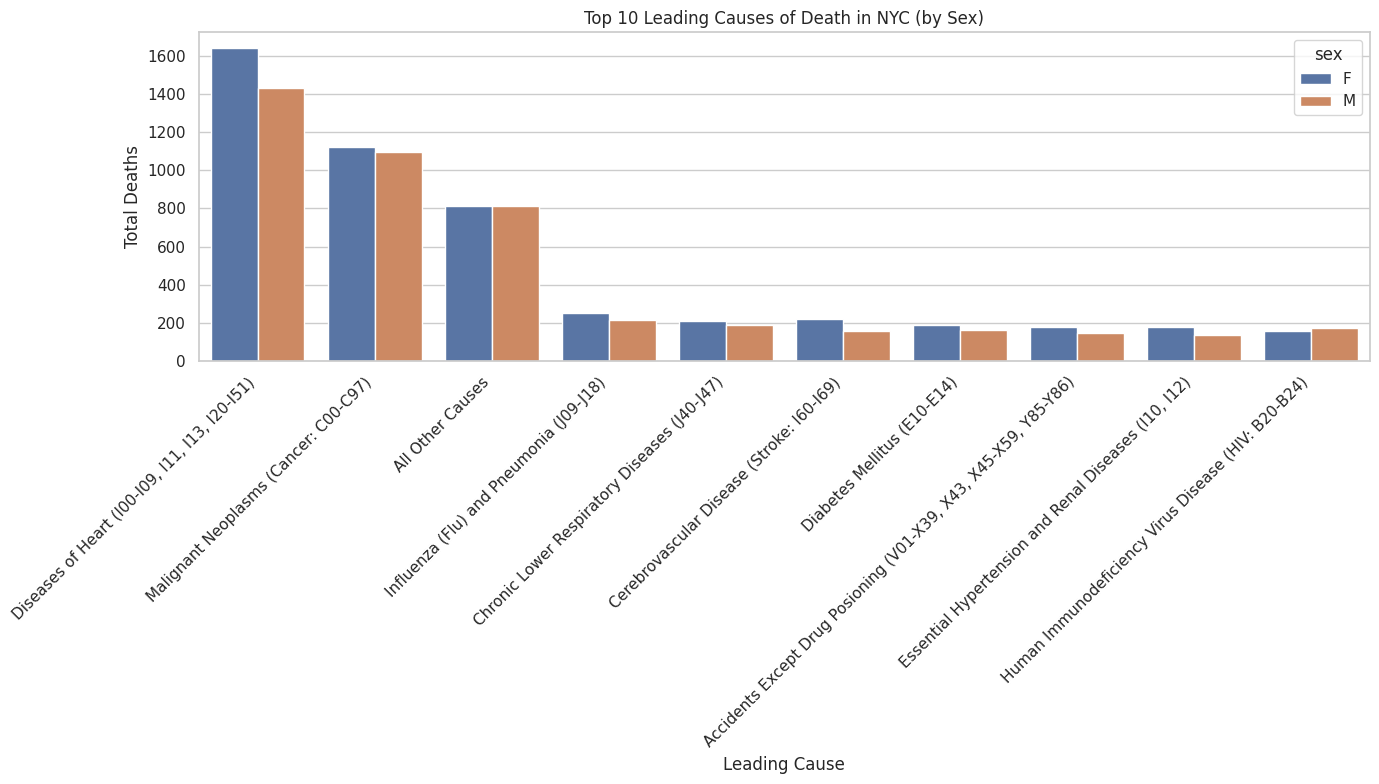

In [108]:

df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')
df['leading_cause'] = df['leading_cause'].astype(str).str.strip()

# Get top 10 causes
top10_causes = (
    df.groupby('leading_cause')['deaths']
      .sum()
      .nlargest(10)
      .index
)

# Filter and reset categories
df_top10 = df[df['leading_cause'].isin(top10_causes)].copy()
df_top10['leading_cause'] = pd.Categorical(df_top10['leading_cause'], categories=top10_causes, ordered=True)

# Plot
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_top10,
    x="leading_cause",
    y="deaths",
    hue="sex",
    errorbar=None
)

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Leading Causes of Death in NYC (by Sex)")
plt.ylabel("Total Deaths")
plt.xlabel("Leading Cause")
plt.tight_layout()
plt.show()


Based on the analysis, the data indicates that females have a higher incidence of mortality-related health conditions compared to males.